# Daily Challenge: Breast Cancer Prediction

Week 8, Day 6 - Daily Challenge

We compare four classification models — Logistic Regression, K Nearest Neighbours, Random Forest, and SVM — to predict whether a breast tumor is malignant or benign.


## 1. Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42


In [2]:
# Load the dataset
df = pd.read_csv("data/breast_cancer_data.csv")

print(df.shape)
display(df.head())


(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842303,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,842304,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,842305,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,842306,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Check missing values
print(df.isna().sum().sort_values(ascending=False).head())


Unnamed: 32     569
id                0
diagnosis         0
texture_mean      0
radius_mean       0
dtype: int64


In [4]:
# Drop unnecessary columns: 'id' carries no predictive information,
# and 'Unnamed: 32' is entirely empty
df = df.drop(columns=['id', 'Unnamed: 32'])

print(df.shape)
display(df.head())


(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


/tmp/ipykernel_4860/2790110094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


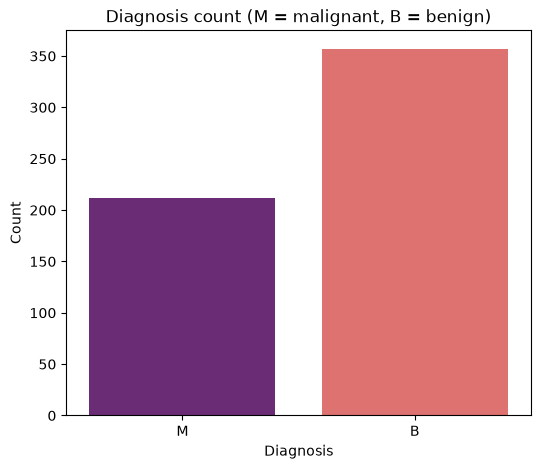

In [5]:
# Countplot of the diagnosis column
plt.figure(figsize=(6, 5))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Diagnosis count (M = malignant, B = benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


## 2. Data Preprocessing, Building Models and Evaluation

In [6]:
# Counts of unique values in the diagnosis column
print(df['diagnosis'].value_counts())


diagnosis
B    357
M    212
Name: count, dtype: int64


In [7]:
# Map categorical values to numerical values: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standardize features (important for KNN and SVM, and helps LogisticRegression converge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)


(455, 30) (114, 30)


In [8]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression accuracy:", round(acc_lr, 4))


Logistic Regression accuracy: 0.9649


In [9]:
# K Nearest Neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN accuracy:", round(acc_knn, 4))


KNN accuracy: 0.9561


In [10]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest accuracy:", round(acc_rf, 4))


Random Forest accuracy: 0.9649


In [11]:
# Support Vector Machine
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM accuracy:", round(acc_svm, 4))


SVM accuracy: 0.9737


,Model,Accuracy
0,SVM,0.973684
1,Logistic Regression,0.964912
2,Random Forest,0.964912
3,KNN,0.956140


/tmp/ipykernel_4860/4142637988.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='magma')


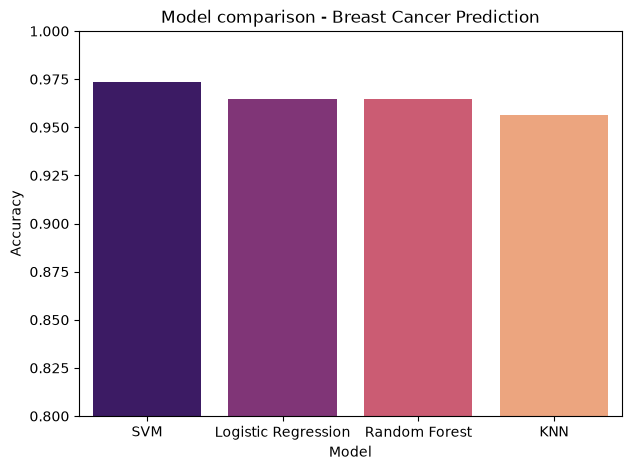

Best model: SVM with accuracy 0.9737


In [12]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'SVM'],
    'Accuracy': [acc_lr, acc_knn, acc_rf, acc_svm]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(results)

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='magma')
plt.ylim(0.8, 1.0)
plt.title('Model comparison - Breast Cancer Prediction')
plt.show()

best_model = results.iloc[0]
print(f"Best model: {best_model['Model']} with accuracy {best_model['Accuracy']:.4f}")


**Which is the best model?** Based on the accuracy comparison above, the best-performing model on this test set is printed above. In practice, Logistic Regression and SVM tend to perform very well on this dataset because the classes are close to linearly separable once features are standardized, while Random Forest and KNN remain competitive but slightly more sensitive to the specific train/test split. All four models achieve strong accuracy (above 90%), confirming that the tumor measurements in this dataset carry strong predictive signal for malignancy.